# Modeling Framework for the 3D Spatial Transcriptomics Simulator

## Overview

The implemented workflow contains four connected stages: preprocessing and construction of reference spatial-domain labels, spatial-domain prediction, cell-type composition prediction and label simulation, and gene-expression count simulation. The corresponding notebooks are `data_process.ipynb`, `domain.ipynb`, `cell_type.ipynb`, and `gene_expression.ipynb`.

The first stage uses the observed multi-slice spatial transcriptomics data to construct a STAIR embedding and reference domain labels. The spatial-domain module then learns a mapping from three-dimensional coordinates to these reference labels and stores its predictions as `pred_region`. The cell-type module first constructs empirical local cell-type composition vectors from the observed cell-type annotations, then learns to predict these local compositions from region-relative coordinates and the predicted domain labels. A simulated cell-type label is sampled from each fitted local composition vector and stored as `pred_celltype`. Finally, the gene-expression module uses `pred_region`, `pred_celltype`, library-size offsets, and spatial radial-basis functions in a gene-wise negative-binomial generalized linear model.

It is useful to distinguish the observed cell-type label from the local cell-type composition. For cell $i$, $C_i$ denotes its observed cell-type label, whereas $\boldsymbol{\pi}_i$ denotes the empirical proportions of different cell types among its spatial neighbors. The vector $\boldsymbol{\pi}_i$ is computed directly from the observed neighboring cell-type labels and is used as the training target of the neural network. The network takes the region-relative coordinates and the predicted domain label as inputs and produces an estimated local composition vector $\widehat{\boldsymbol{\pi}}_i$. A simulated cell-type label $\widehat C_i$ is subsequently sampled from the categorical distribution defined by $\widehat{\boldsymbol{\pi}}_i$.


## Data preprocessing and reference domain construction

The preprocessing notebook reads the MERFISH mouse hypothalamic preoptic-region dataset containing 12 slices, indexed by A0, A1, ..., A11. STAIR is applied with `batch` as the slice indicator and `spatial` as the within-slice spatial coordinate. The slices are supplied to STAIR in their known order. The implemented sequence consists of STAIR preparation, preprocessing, latent representation learning, heterogeneous graph construction, HGAT training, and prediction. The resulting aligned representation is stored in `adata.obsm["STAIR"]`.

Let $\boldsymbol{u}_i\in\mathbb{R}^p$ denote the STAIR representation of spot or cell $i$. The code clusters these embeddings by a Gaussian mixture model fitted with `Mclust`, using $K_D=13$ components and the `EEE` covariance specification. Thus, the working mixture model can be written as

$$
\boldsymbol{u}_i\mid R_i=d
\sim
\mathcal{N}_p(\boldsymbol{m}_d,\boldsymbol{\Sigma}),
\qquad
d=1,\ldots,K_D,
$$

where the `EEE` specification imposes equal volume, shape, and orientation across mixture components. The mixture fit uses random seed 2022. The posterior classification returned by `Mclust` defines the reference domain label $R_i$. These labels are stored in `adata.obs["STAIR"]`. The preprocessing notebook also initially copies them to `pred_region`, but this column is subsequently overwritten by the predictions from the spatial-domain neural network.

Accordingly, the labels called "domains" in the downstream code are not manually supplied anatomical annotations. They are data-driven reference clusters obtained by applying `Mclust` to the STAIR embedding.

## Spatial-domain prediction

### Input and target labels

For spot or cell $i$, let

$$
\boldsymbol{s}_i=(x_i,y_i,z_i)^\top
$$

denote the three-dimensional coordinate read from `adata.obsm["spatial_3d"]`. The supervised target is the STAIR-derived reference domain label

$$
R_i\in\{1,\ldots,K_D\}.
$$

The labels are converted to integer indices by `LabelEncoder`. Each coordinate dimension is standardized by `StandardScaler`. In notation, the transformed coordinate is

$$
\widetilde{s}_{iq}
=
\frac{s_{iq}-\widehat m_q}{\widehat\sigma_q},
\qquad q\in\{x,y,z\},
$$

where $\widehat m_q$ and $\widehat\sigma_q$ are the empirical mean and the scale used by `StandardScaler`. The code does not explicitly add $10^{-8}$ in this module. Under `StandardScaler`, a coordinate with zero empirical variance is assigned a unit scaling factor rather than divided by zero.

The standardized observations are divided into an 80% training set and a 20% validation set by a stratified split with random state 42.

### Neural-network model

The domain network is a feed-forward multilayer perceptron with layer widths

$$
3\longrightarrow256\longrightarrow256\longrightarrow128\longrightarrow K_D.
$$

A ReLU activation follows each hidden linear layer. Let $f_d(\widetilde{\boldsymbol{s}}_i;\boldsymbol{\theta}_D)$ denote the output logit for domain $d$. Although the PyTorch network returns logits directly, the implied class probabilities are

$$
p_{id}^{D}
=
P(R_i=d\mid\boldsymbol{s}_i)
=
\frac{\exp\{f_d(\widetilde{\boldsymbol{s}}_i;\boldsymbol{\theta}_D)\}}
{\sum_{d'=1}^{K_D}\exp\{f_{d'}(\widetilde{\boldsymbol{s}}_i;\boldsymbol{\theta}_D)\}},
\qquad d=1,\ldots,K_D.
$$

The parameters are estimated by minimizing the multiclass cross-entropy loss over the training set,

$$
\mathcal{L}_D(\boldsymbol{\theta}_D)
=
-\frac{1}{n_{\mathrm{tr}}}
\sum_{i\in\mathcal{I}_{\mathrm{tr}}}
\sum_{d=1}^{K_D}
\mathbf{1}\{R_i=d\}\log p_{id}^{D}.
$$

The code uses the Adam optimizer with learning rate $10^{-3}$, batch size 512, and 100 epochs. The Python, NumPy, and PyTorch random seeds are set to 20260517 before model construction and training. (Validation accuracy is reported every five epochs, but it is not used for early stopping or model selection.)

After training, the fitted network is evaluated on all observations and the predicted domain is

$$
\widehat D_i
=
\arg\max_{1\leq d\leq K_D}p_{id}^{D}.
$$

The decoded labels are stored in `adata.obs["pred_region"]`. Therefore, `pred_region` contains argmax predictions from the coordinate-based network rather than categorical draws from the domain probabilities.

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read('../adata_backup.h5ad')
adata

AnnData object with n_obs × n_vars = 64373 × 155
    obs: 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'slices', 'Coord_X', 'Coord_Y', 'x', 'y', 'z', 'cell_type', 'batch', 'n_genes', 'size', 'STAIR', 'pred_region'
    var: 'n_cells'
    uns: 'batch_colors', 'cell_type_colors', 'log1p'
    obsm: 'STAIR', 'STAIR_clean', 'latent', 'spatial', 'spatial_2d_raw', 'spatial_2d_raw_rotate', 'spatial_2d_μm', 'spatial_2d_μm_rotate', 'spatial_3d', 'spatial_3d_raw', 'spatial_3d_raw_rotate', 'spatial_3d_μm', 'spatial_3d_μm_rotate'
    layers: 'Denoise', 'counts', 'noise1', 'noise2', 'noise3', 'noise4'

In [2]:
counts = adata.layers["counts"]

print(counts.min(), counts.max())
print(np.unique(counts[:100]))

0.0 369.59537
[0.0000000e+00 4.4100001e-05 6.8900001e-05 ... 1.4752515e+02 1.5049559e+02
 2.1176491e+02]


In [3]:
X = adata.obsm["spatial_3d"]
X

array([[   3.23750397,   17.63871325,  550.        ],
       [   6.8853361 ,   30.93521051,  550.        ],
       [   5.22646391,   42.32971919,  550.        ],
       ...,
       [1717.05240568, 1600.84306055,    0.        ],
       [1791.25410486, 1778.67357655,    0.        ],
       [1638.63571524, 1606.32942073,    0.        ]], shape=(64373, 3))

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# coordinates
X = adata.obsm["spatial_3d"]

# region labels
region_labels = adata.obs["STAIR"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(region_labels)

num_classes = len(le.classes_)
print("Region number:", num_classes)


X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)



class SpatialMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            
            nn.Linear(256, 256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

Region number: 13


In [5]:
import random
import numpy as np
import torch
seed = 20260517

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


input_dim = X_train.shape[1]  # 2 or 3
hidden_dim = 128

model = SpatialMLP(input_dim, num_classes)

batch_size = 512
epochs = 100
lr = 1e-3

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        
        logits = model(xb)
        loss = criterion(logits, yb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # validation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    
    val_acc = correct / total
    
    if (epoch + 1) % 5 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

model.eval()

X_all = torch.tensor(X_scaled, dtype=torch.float32)

with torch.no_grad():
    logits = model(X_all)
    pred_idx = torch.argmax(logits, dim=1).numpy()

pred_region = le.inverse_transform(pred_idx)

adata.obs["pred_region"] = pred_region

Epoch 005 | Loss: 0.7255 | Val Acc: 0.7120
Epoch 010 | Loss: 0.6413 | Val Acc: 0.7550
Epoch 015 | Loss: 0.5959 | Val Acc: 0.7677
Epoch 020 | Loss: 0.5657 | Val Acc: 0.7776
Epoch 025 | Loss: 0.5471 | Val Acc: 0.7839
Epoch 030 | Loss: 0.5294 | Val Acc: 0.7890
Epoch 035 | Loss: 0.5154 | Val Acc: 0.7958
Epoch 040 | Loss: 0.5024 | Val Acc: 0.7967
Epoch 045 | Loss: 0.4978 | Val Acc: 0.7994
Epoch 050 | Loss: 0.4864 | Val Acc: 0.8032
Epoch 055 | Loss: 0.4740 | Val Acc: 0.7953
Epoch 060 | Loss: 0.4730 | Val Acc: 0.8033
Epoch 065 | Loss: 0.4653 | Val Acc: 0.8071
Epoch 070 | Loss: 0.4567 | Val Acc: 0.8086
Epoch 075 | Loss: 0.4534 | Val Acc: 0.8057
Epoch 080 | Loss: 0.4431 | Val Acc: 0.8106
Epoch 085 | Loss: 0.4366 | Val Acc: 0.8195
Epoch 090 | Loss: 0.4347 | Val Acc: 0.8144
Epoch 095 | Loss: 0.4267 | Val Acc: 0.8213
Epoch 100 | Loss: 0.4230 | Val Acc: 0.8267


In [6]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../saved_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the neural network and all preprocessing required for inference.
torch.save(
    {k: v.detach().cpu() for k, v in model.state_dict().items()},
    MODEL_DIR / "domain_mlp_state.pt"
)
joblib.dump(
    {
        "input_dim": int(input_dim),
        "num_classes": int(num_classes),
        "scaler": scaler,
        "label_encoder": le,
        "spatial_key": "spatial_3d"
    },
    MODEL_DIR / "domain_preprocess.joblib"
)
print("Saved domain model to", MODEL_DIR.resolve())


Saved domain model to /Users/yyq/Documents/MyDocuments/project/吴浩老师 3d ST simulator/code/20260525 志伟源代码+原始数据/saved_models


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

save_dir = "region_analysis_figures"
os.makedirs(save_dir, exist_ok=True)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_real_vs_sim_flip(
        adata,
        slices,
        real_key="STAIR",
        sim_key="pred_region",
        save_path=None):

    # ---------- 1 color dict ----------
    stair_labels = (
        adata.obs[real_key]
        .astype(float)
        .astype(int)
        .unique()
    )

    stair_labels = sorted(stair_labels)

    base_colors = plt.cm.tab20(np.linspace(0,1,20))

    region_color_dict = {
        label: base_colors[i]
        for i,label in enumerate(stair_labels)
    }

    # ---------- 2 create figure ----------
    fig, axes = plt.subplots(
        2,
        len(slices),
        figsize=(5*len(slices),8)
    )

    if len(slices) == 1:
        axes = np.array([[axes[0]],[axes[1]]])

    # ---------- 3 plot ----------
    for i,slc in enumerate(slices):

        sub = adata[adata.obs["batch"] == slc]

        x = sub.obsm["spatial"][:,0]
        y = sub.obsm["spatial"][:,1]

        real_vals = sub.obs[real_key].astype(float).astype(int).values
        sim_vals  = sub.obs[sim_key].astype(float).astype(int).values

        real_colors = [region_color_dict[r] for r in real_vals]
        sim_colors  = [region_color_dict.get(r,(0,0,0,1)) for r in sim_vals]

        # ---------- Real ----------
        ax = axes[0,i]
        ax.scatter(x,y,c=real_colors,s=4)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        # Key: Flip vertically
        ax.set_ylim(ax.get_ylim()[::-1])

        # ---------- Sim ----------
        ax = axes[1,i]
        ax.scatter(x,y,c=sim_colors,s=4)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        # Key: Flip vertically
        ax.set_ylim(ax.get_ylim()[::-1])


    axes[0,0].set_ylabel("real", fontsize=24, rotation=0, labelpad=40, va="center")
    axes[1,0].set_ylabel("simu", fontsize=24, rotation=0, labelpad=40, va="center")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,dpi=300,bbox_inches="tight")

    plt.show()


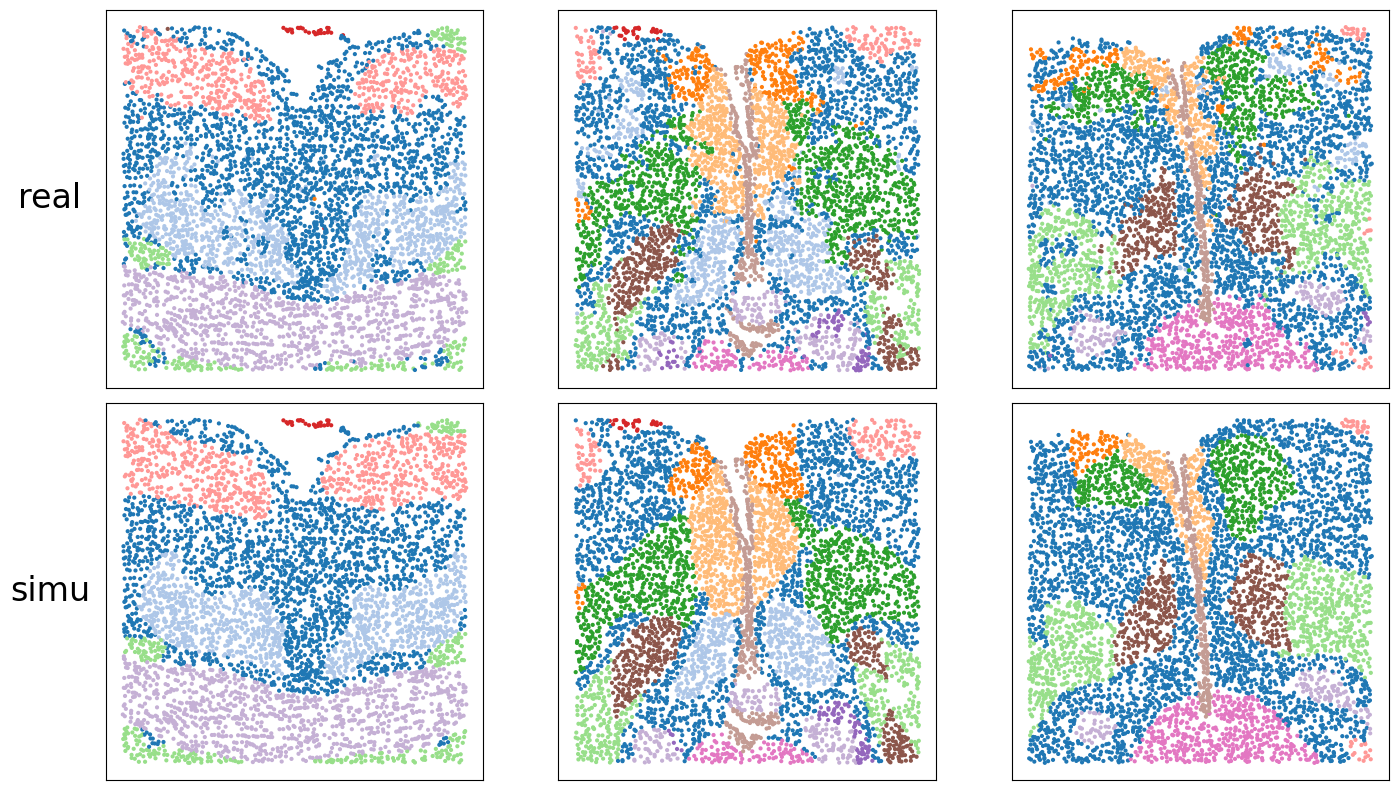

In [9]:
# from matplotlib import font_manager

# font_cn = font_manager.FontProperties(
#     fname="/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
# )


plot_real_vs_sim_flip(
    adata,
    slices=["A1","A6","A11"],
    save_path="region_analysis_figures/real_vs_sim.png"
)

In [10]:
# plot_real_vs_sim_locked

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_region_proportion_locked(adata,
                                  real_key="STAIR",
                                  sim_key="pred_region",
                                  save_path=None):

    # -------- 1 Convert to integer labels --------
    real = adata.obs[real_key].astype(float).astype(int)
    sim  = adata.obs[sim_key].astype(float).astype(int)

    # -------- 2 Fix the region order --------
    regions = sorted(real.unique())

    # -------- 3 compute the proportions --------
    real_prop = real.value_counts(normalize=True).reindex(regions, fill_value=0)
    sim_prop  = sim.value_counts(normalize=True).reindex(regions, fill_value=0)

    x = np.arange(len(regions))
    width = 0.35

    plt.figure(figsize=(10,5))

    plt.bar(x - width/2, real_prop.values, width,
            label="Real", alpha=0.9)

    plt.bar(x + width/2, sim_prop.values, width,
            label="Sim", alpha=0.9)

    plt.xticks(x, regions)
    plt.xlabel("Region")
    plt.ylabel("Proportion")
    plt.title("Region Proportion Comparison")
    plt.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

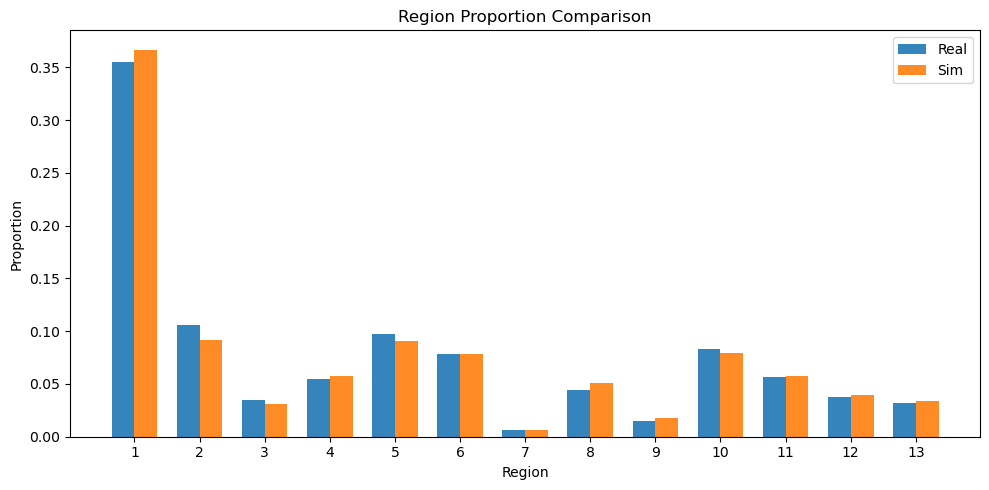

In [12]:
plot_region_proportion_locked(
    adata,
    save_path="region_analysis_figures/region_proportion.png"
)

In [13]:
adata.write_h5ad("../adata_backup_with_pred_region.h5ad")